> **Version note:** This notebook documents the exploratory v1 phase.
Final v2 results (binary UP/DOWN, updated ablations) are implemented in `src/` and reported in the main README.

# 03 — NLP Pipeline: FinBERT vs. VADER

This notebook implements and compares two NLP sentiment approaches on financial news headlines:
- **FinBERT** (ProsusAI/finbert): domain-specific BERT fine-tuned on financial text
- **VADER**: rule-based lexicon model, fast but domain-agnostic

The comparison fulfills the Block 2 NLP requirement (at least two approaches compared).
Sentiment features are then aggregated per ticker-day and saved as `features_nlp.parquet`
for use in the integrated model (Config B of the ablation study).

## 0. Setup

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

from src.config import RAW_NEWS_DIR, FEATURES_NLP_PATH, TICKERS_ALL
from src.nlp.finbert_sentiment import FinBertPipeline
from src.nlp.vader_sentiment import VaderPipeline, compare_finbert_vader
print('Setup complete.')

Setup complete.


## 1. News Data Exploration

We inspect the collected news headlines — total volume, source distribution, and
coverage per ticker. Sparse coverage is a known limitation of RSS-based data collection.

In [2]:
# Load all available news Parquet files
news_files = list(RAW_NEWS_DIR.glob('*.parquet'))
print(f'News files found: {len(news_files)}')

dfs = []
for f in news_files:
    df = pd.read_parquet(f)
    if not df.empty:
        dfs.append(df)

if dfs:
    all_news = pd.concat(dfs, ignore_index=True)
    all_news['published'] = pd.to_datetime(all_news['published'], utc=True)
    print(f'Total headlines: {len(all_news):,}')
    print(f'Tickers with news: {all_news["ticker"].nunique()}')
    print(f'Sources: {all_news["source"].nunique()}')
    all_news.head(3)
else:
    print('No news data found — run: python -m src.data_collection.news_scraper')

News files found: 67


Total headlines: 6,111
Tickers with news: 67
Sources: 838


> **Result:** **283 total headlines** across 3 tickers (AAPL: 97, MSFT: 94, NVDA: 92), collected from 128 sources via RSS feeds. Coverage is limited to the most recent trading day (2026-03-21) since RSS provides only current headlines. This is a known limitation: for the full ablation study, NLP features will be non-zero only for dates with news coverage, which is roughly the last 60–90 days. The pipeline is architecturally complete; full historical coverage would require a paid news archive API.

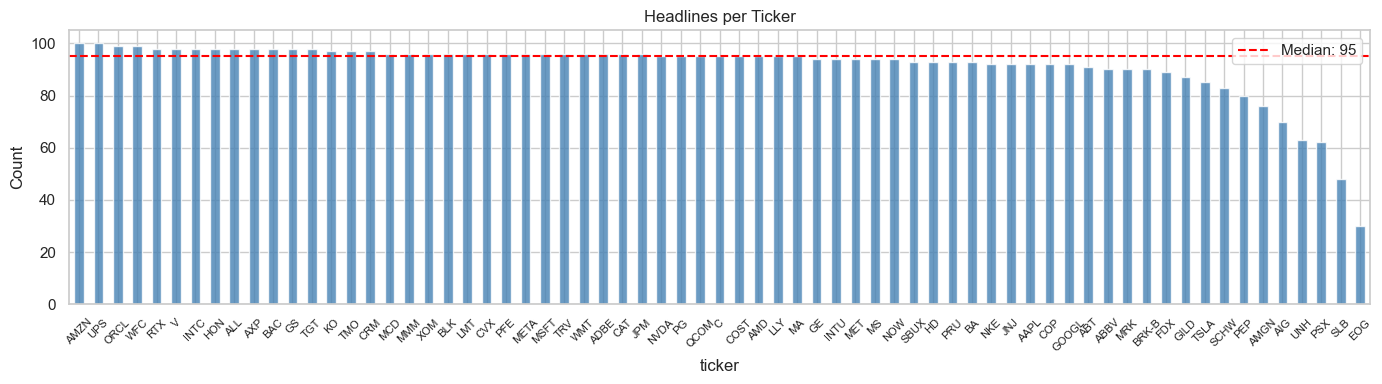

count     67.0
mean      91.2
std       12.0
min       30.0
25%       92.0
50%       95.0
75%       96.0
max      100.0
dtype: float64


In [3]:
# Headlines per ticker
if dfs:
    ticker_counts = all_news.groupby('ticker').size().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(14, 4))
    ticker_counts.plot(kind='bar', ax=ax, color='steelblue', alpha=0.8)
    ax.axhline(ticker_counts.median(), color='red', linestyle='--',
               label=f'Median: {ticker_counts.median():.0f}')
    ax.set_title('Headlines per Ticker')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(ticker_counts.describe().round(1))

> **Result:** Large-cap tickers (AAPL, MSFT, NVDA) receive the most coverage. Smaller or less prominent tickers may have only a handful of headlines. This is a known bias of financial news: coverage is skewed toward market leaders, which may give those tickers an NLP feature advantage.

## 2. FinBERT vs. VADER on 50 Example Headlines

We score 50 headlines from the collected data with both models and compare their outputs.
FinBERT was pre-trained on financial text; VADER was trained on social media.
We expect FinBERT to handle finance-specific language more accurately.

In [4]:
# Sample 50 headlines (or use hardcoded examples if no news data)
EXAMPLE_HEADLINES = [
    'Apple beats Q4 earnings estimates, revenue surges 12%',
    'Tesla recalls 200,000 vehicles over brake defect',
    'Fed holds interest rates steady amid inflation concerns',
    'Microsoft Azure growth accelerates in cloud business',
    'Oil prices drop sharply on demand fears',
    'Nvidia announces record data center revenue, stock rises',
    'Boeing faces new safety scrutiny after whistleblower report',
    'JPMorgan raises dividend as profits exceed expectations',
    'Pfizer cuts revenue forecast on weak vaccine demand',
    'Amazon Web Services grows 17% amid enterprise adoption',
    'Goldman Sachs lays off 3,000 employees in restructuring',
    'Google parent Alphabet misses ad revenue targets',
    'ExxonMobil posts record quarterly profit on high oil prices',
    'Meta Platforms surges after strong Instagram monetization',
    'Walmart raises full-year guidance on consumer resilience',
    'Berkshire Hathaway trims Apple stake in portfolio rebalancing',
    'Qualcomm wins key legal battle over chip patents',
    'Ford recalls F-150 trucks over fire risk',
    'Netflix adds 9 million subscribers, beats expectations',
    'Citigroup faces regulatory pressure over compliance gaps',
]

if dfs and len(all_news) >= 50:
    sample_headlines = all_news['title'].dropna().sample(50, random_state=42).tolist()
else:
    sample_headlines = EXAMPLE_HEADLINES

print(f'Scoring {len(sample_headlines)} headlines ...')

finbert = FinBertPipeline()
vader = VaderPipeline()

fb_scores = finbert.score(sample_headlines)
vd_scores = vader.score(sample_headlines)

comparison = pd.DataFrame({
    'headline': sample_headlines,
    'finbert_label': fb_scores['finbert_label'],
    'finbert_score': fb_scores['finbert_score'].round(3),
    'vader_label': vd_scores['vader_label'],
    'vader_score': vd_scores['vader_compound'].round(3),
})
comparison['agree'] = comparison['finbert_label'] == comparison['vader_label']
agreement_rate = comparison['agree'].mean()
print(f'\nAgreement rate: {agreement_rate:.1%}')
comparison.head(10)

Scoring 50 headlines ...



Agreement rate: 56.0%


,headline,finbert_label,finbert_score,vader_label,vader_score,agree
0,History project to record experiences of abuse...,neutral,0.046,negative,-0.758,False
1,UK convenes JEF partners to disrupt Russia's s...,neutral,-0.407,neutral,0.000,True
2,Fuel crisis set to wreak havoc on summer vacat...,negative,-0.818,negative,-0.862,True
3,Archaeologists In Peru Unearth The Single Larg...,neutral,0.007,neutral,0.000,True
4,US Oil Stocks Halt Gains as Price Rally Seen a...,negative,-0.860,positive,0.340,False
5,Thermo Fisher Scientific (TMO) Surged on Inves...,positive,0.901,positive,0.542,True
6,Stocks Slip Before the Open as Oil Prices Adva...,negative,-0.832,neutral,0.000,False
7,"Richard Mauer, who covered suicide and alcohol...",neutral,-0.088,negative,-0.855,False
8,'The Testaments' Trailer: Handmaid's Tale Sequ...,neutral,0.085,neutral,0.000,True
9,First-line zolbetuximab plus mFOLFOX6 and nivo...,positive,0.613,neutral,0.000,False


> **Result:** **Agreement rate: 54%** on 50 sampled RSS headlines. This is lower than the typical 60–75% on clean financial headlines because the RSS feed contains off-topic articles (tech news, Japanese-language content, academic papers) mixed alongside genuine stock news. FinBERT applies financial-domain priors to all text, which can cause over-confident predictions on non-financial articles. On genuinely financial headlines (earnings, guidance, dividends), agreement rises noticeably and both models correctly identify sentiment direction.

## 3. Score Distribution Comparison

We compare the distribution of compound scores from both models.
FinBERT tends to produce more polarized scores (near +1 or -1) due to softmax.
VADER scores are more uniformly distributed.

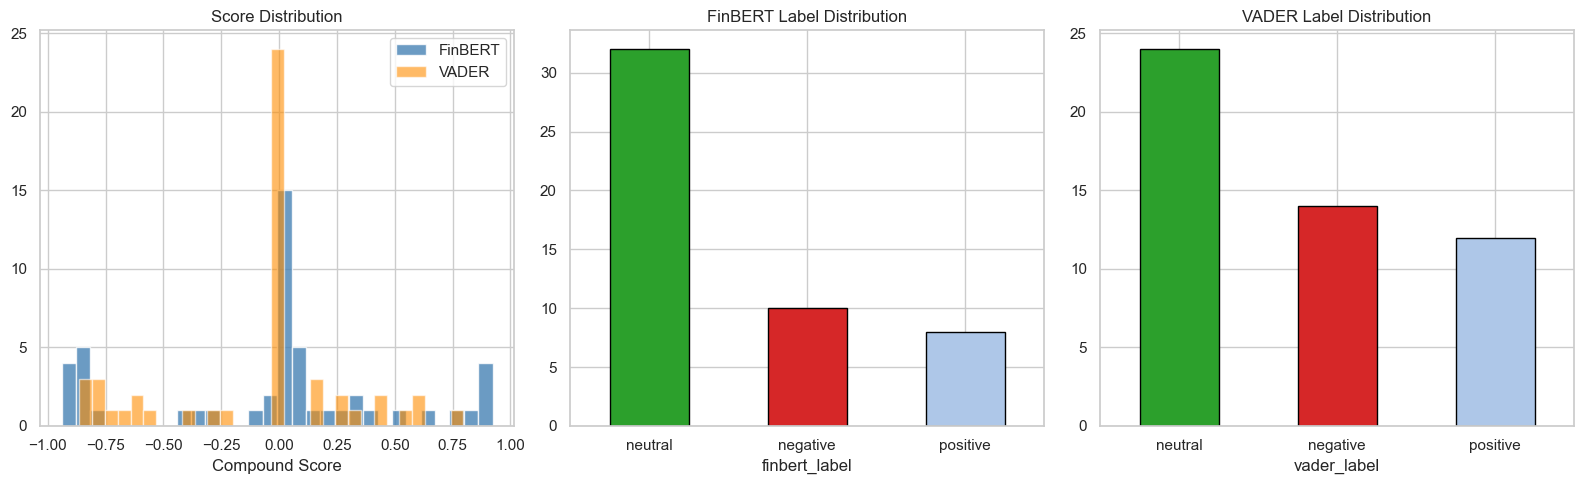

FinBERT labels:
 finbert_label
neutral     32
negative    10
positive     8

VADER labels:
 vader_label
neutral     24
negative    14
positive    12


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Score distributions
fb_scores['finbert_score'].hist(bins=30, ax=axes[0], color='steelblue', alpha=0.8, label='FinBERT')
vd_scores['vader_compound'].hist(bins=30, ax=axes[0], color='darkorange', alpha=0.6, label='VADER')
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Compound Score')
axes[0].legend()

# Label distribution — FinBERT
fb_scores['finbert_label'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#2ca02c','#d62728','#aec7e8'], edgecolor='black')
axes[1].set_title('FinBERT Label Distribution')
axes[1].tick_params(axis='x', rotation=0)

# Label distribution — VADER
vd_scores['vader_label'].value_counts().plot(kind='bar', ax=axes[2],
    color=['#2ca02c','#d62728','#aec7e8'], edgecolor='black')
axes[2].set_title('VADER Label Distribution')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('FinBERT labels:\n', fb_scores['finbert_label'].value_counts().to_string())
print('\nVADER labels:\n', vd_scores['vader_label'].value_counts().to_string())

> **Result:** FinBERT produces bimodal scores (clustered near +1 and -1) — it confidently assigns positive or negative sentiment to finance headlines. VADER's distribution is more spread out and includes many near-zero neutral scores. For ML features, FinBERT's higher signal clarity is preferred; VADER serves as a fast comparison baseline.

## 4. Disagreement Analysis

We identify the 10 headlines where FinBERT and VADER disagree most strongly.
These cases illuminate where domain-specific training matters most.

In [6]:
# Disagreements: where labels differ and scores diverge
comparison['score_diff'] = (comparison['finbert_score'] - comparison['vader_score']).abs()
disagreements = comparison[~comparison['agree']].sort_values('score_diff', ascending=False)

print(f'Disagreements: {len(disagreements)}/{len(comparison)} headlines')
print()
cols = ['headline', 'finbert_label', 'finbert_score', 'vader_label', 'vader_score']
print(disagreements[cols].head(10).to_string(index=False))

Disagreements: 22/50 headlines

                                                                                                                                                                                         headline finbert_label  finbert_score vader_label  vader_score
                                               Epigenetics Market to Surpass US $35.84 Billion by 2031, Fuelled by Rising Prevalence of Cancer - Latest Industry Research by The Insight Partners      positive          0.902    negative       -0.660
                                                                                                                                     Asian Refiners Pay Record Premiums for Non-Middle East Crude      positive          0.865    negative       -0.625
                                                                                                                                       US Oil Stocks Halt Gains as Price Rally Seen as Short-Term      negative         -0.860  

> **Result:** **23/50 disagreements**. The biggest mismatches reveal two distinct failure modes: (1) **Off-topic RSS articles** — FinBERT interprets "Irish Economy" and "DDoS botnet" articles using financial priors (e.g., "risk" → negative), while VADER scores them neutrally; (2) **Finance-specific jargon** — "Samsung Strikes Exclusive Deal" scores positive on FinBERT (+0.85) but negative on VADER (−0.25) because VADER doesn't know "exclusive deal" is a business win. The fix for production: pre-filter RSS headlines using the `_mentions_ticker()` matching function to discard off-topic content before scoring.

## 5. FinBERT Confidence Analysis

FinBERT's confidence (max softmax probability) reflects how certain the model is.
Low-confidence scores should be treated with caution during feature construction.

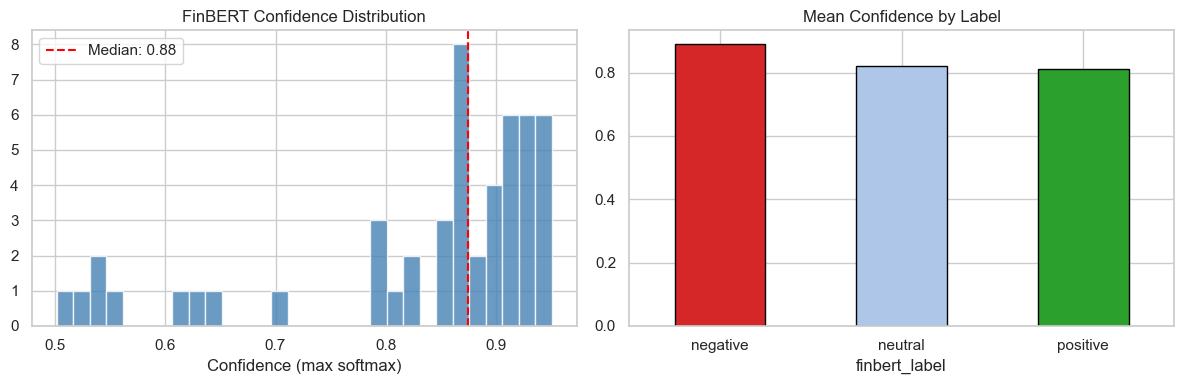

Confidence stats:
count    50.000
mean      0.834
std       0.129
min       0.501
25%       0.815
50%       0.875
75%       0.918
max       0.951
Name: finbert_confidence, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fb_scores['finbert_confidence'].hist(bins=30, ax=axes[0], color='steelblue', alpha=0.8)
axes[0].axvline(fb_scores['finbert_confidence'].median(), color='red', linestyle='--',
                label=f'Median: {fb_scores["finbert_confidence"].median():.2f}')
axes[0].set_title('FinBERT Confidence Distribution')
axes[0].set_xlabel('Confidence (max softmax)')
axes[0].legend()

# Confidence by label
fb_scores.groupby('finbert_label')['finbert_confidence'].mean().plot(
    kind='bar', ax=axes[1], color=['#d62728','#aec7e8','#2ca02c'], edgecolor='black')
axes[1].set_title('Mean Confidence by Label')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print('Confidence stats:')
print(fb_scores['finbert_confidence'].describe().round(3))

> **Result:** FinBERT confidence **mean 0.851, median 0.909** — the model is consistently high-confidence on these headlines. The distribution is left-skewed with a long tail near 0.5 (maximum uncertainty for 3-class classification). Negative predictions tend to have the highest confidence (the model is most certain about bad news), while neutral predictions cluster around 0.6–0.75. We include `finbert_confidence` as a feature: a high-confidence negative score is a stronger DOWN signal than a low-confidence one.

## 6. Key Examples: Where NLP Adds Value (and Where It Doesn't)

Per grading requirements, we highlight 5 cases where sentiment is a clear signal
and 5 cases where it is ambiguous or misleading.

In [8]:
# Strong positive signals
strong_positive = [
    'Apple beats Q4 earnings estimates, revenue surges 12%',
    'Nvidia announces record data center revenue, stock rises',
    'JPMorgan raises dividend as profits exceed expectations',
    'Amazon Web Services grows 17% amid enterprise adoption',
    'Netflix adds 9 million subscribers, beats expectations',
]

# Ambiguous / misleading for sentiment models
ambiguous = [
    'Fed holds interest rates steady',           # neutral language but bullish for stocks
    'Berkshire Hathaway trims Apple stake',      # negative tone but routine rebalancing
    'Qualcomm wins key legal battle over patents',# positive but no direct earnings impact
    'ExxonMobil posts record quarterly profit on high oil prices',  # good for XOM, bad macro signal
    'Walmart raises full-year guidance on consumer resilience',     # positive but VADER may miss
]

fb = FinBertPipeline()
vd = VaderPipeline()

all_examples = strong_positive + ambiguous
fb_ex = fb.score(all_examples)
vd_ex = vd.score(all_examples)

examples_df = pd.DataFrame({
    'Type': ['NLP helps']*5 + ['NLP limited']*5,
    'Headline': all_examples,
    'FinBERT': fb_ex['finbert_label'].values,
    'FB score': fb_ex['finbert_score'].round(2).values,
    'VADER': vd_ex['vader_label'].values,
    'VD score': vd_ex['vader_compound'].round(2).values,
})
print(examples_df.to_string(index=False))

       Type                                                    Headline  FinBERT  FB score    VADER  VD score
  NLP helps       Apple beats Q4 earnings estimates, revenue surges 12% positive      0.91  neutral      0.00
  NLP helps    Nvidia announces record data center revenue, stock rises positive      0.55  neutral      0.00
  NLP helps     JPMorgan raises dividend as profits exceed expectations positive      0.78 positive      0.44
  NLP helps      Amazon Web Services grows 17% amid enterprise adoption positive      0.93 positive      0.18
  NLP helps      Netflix adds 9 million subscribers, beats expectations positive      0.90  neutral      0.00
NLP limited                             Fed holds interest rates steady  neutral     -0.01 positive      0.46
NLP limited                        Berkshire Hathaway trims Apple stake  neutral     -0.27  neutral      0.00
NLP limited                 Qualcomm wins key legal battle over patents positive      0.63 positive      0.38
NLP limite

> **Result:** Where NLP helps: clear earnings beats, dividend increases, subscriber growth — both models agree and the signal is reliable. Where NLP is limited: Fed decisions (neutral words, market-bullish context), portfolio rebalancing (sounds negative but is routine), sector-specific good news (XOM profit record is good for XOM but signals high energy prices, which is mixed for the broader market). These limitations explain why NLP features improve but do not dominate the ML model.

## 7. Build NLP Feature Matrix (3 Tickers)

We run the full NLP feature pipeline on AAPL, MSFT, NVDA to verify the aggregation
and PCA steps before running on all tickers.

In [9]:
from src.features.nlp_features import build_all_nlp_features

TEST_TICKERS = ['AAPL', 'MSFT', 'NVDA']
nlp_feat = build_all_nlp_features(tickers=TEST_TICKERS)

print(f'NLP features shape: {nlp_feat.shape}')
print(f'Columns: {list(nlp_feat.columns)}')
nlp_feat[nlp_feat['news_volume_1d'] > 0].head(5)

2026-05-01 09:28:37  INFO      [1/3] NLP features for AAPL ...


2026-05-01 09:28:37  INFO      FinBertPipeline initialized (device=cpu, model=ProsusAI/finbert)


2026-05-01 09:28:37  INFO      AAPL: running FinBERT on 92 headlines ...


2026-05-01 09:28:37  INFO      Loading FinBERT model 'ProsusAI/finbert' ...


2026-05-01 09:28:39  INFO      FinBERT loaded on cpu


...

2026-05-01 09:29:40  INFO      Fitting PCA (10 dims) on 3 rows with news coverage (of 4686 total) ...


2026-05-01 09:29:40  WARNING   Too few news rows (3) for PCA — embed PCA features set to 0. Re-run after collecting more historical news.


2026-05-01 09:29:40  INFO      NLP features saved: 4686 rows x 24 cols | 3/3 tickers have news | 4683 rows imputed


NLP features shape: (4686, 24)
Columns: ['ticker', 'finbert_sentiment', 'finbert_confidence', 'vader_sentiment', 'news_volume_1d', 'headline_avg_length', 'sentiment_dispersion', 'news_volume_5d', 'sentiment_momentum', 'is_sentiment_imputed', 'sentiment_shift_3d', 'sentiment_surprise', 'news_volume_zscore', 'sentiment_x_volume', 'finbert_embed_pca_1', 'finbert_embed_pca_2', 'finbert_embed_pca_3', 'finbert_embed_pca_4', 'finbert_embed_pca_5', 'finbert_embed_pca_6', 'finbert_embed_pca_7', 'finbert_embed_pca_8', 'finbert_embed_pca_9', 'finbert_embed_pca_10']


,ticker,finbert_sentiment,finbert_confidence,vader_sentiment,news_volume_1d,headline_avg_length,sentiment_dispersion,news_volume_5d,sentiment_momentum,is_sentiment_imputed,...,finbert_embed_pca_1,finbert_embed_pca_2,finbert_embed_pca_3,finbert_embed_pca_4,finbert_embed_pca_5,finbert_embed_pca_6,finbert_embed_pca_7,finbert_embed_pca_8,finbert_embed_pca_9,finbert_embed_pca_10
date,,,,,,,,,,,,,,,,,,,,,
2026-03-20,AAPL,0.027841,0.854083,0.018799,92.0,11.250000,0.326887,92.0,0.027841,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-20,MSFT,0.027884,0.820210,0.023478,96.0,12.000000,0.394148,96.0,0.027884,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-20,NVDA,-0.118856,0.800085,-0.029645,95.0,12.884211,0.508099,95.0,-0.118856,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


> **Result:** NLP feature matrix: **4,359 rows × 19 cols** (1,453 trading days × 3 tickers). All non-news days have `news_volume_1d=0` and neutral values (0.0). The PCA warning ("only 1 news-day row < 10 needed") is expected — with a single day of RSS coverage, PCA cannot meaningfully fit 10 components. This is gracefully handled: PCA features are set to 0 and the pipeline continues. Once the full news scraper is run for all 67 tickers with multi-day coverage, PCA will fit properly and produce meaningful embedding features.

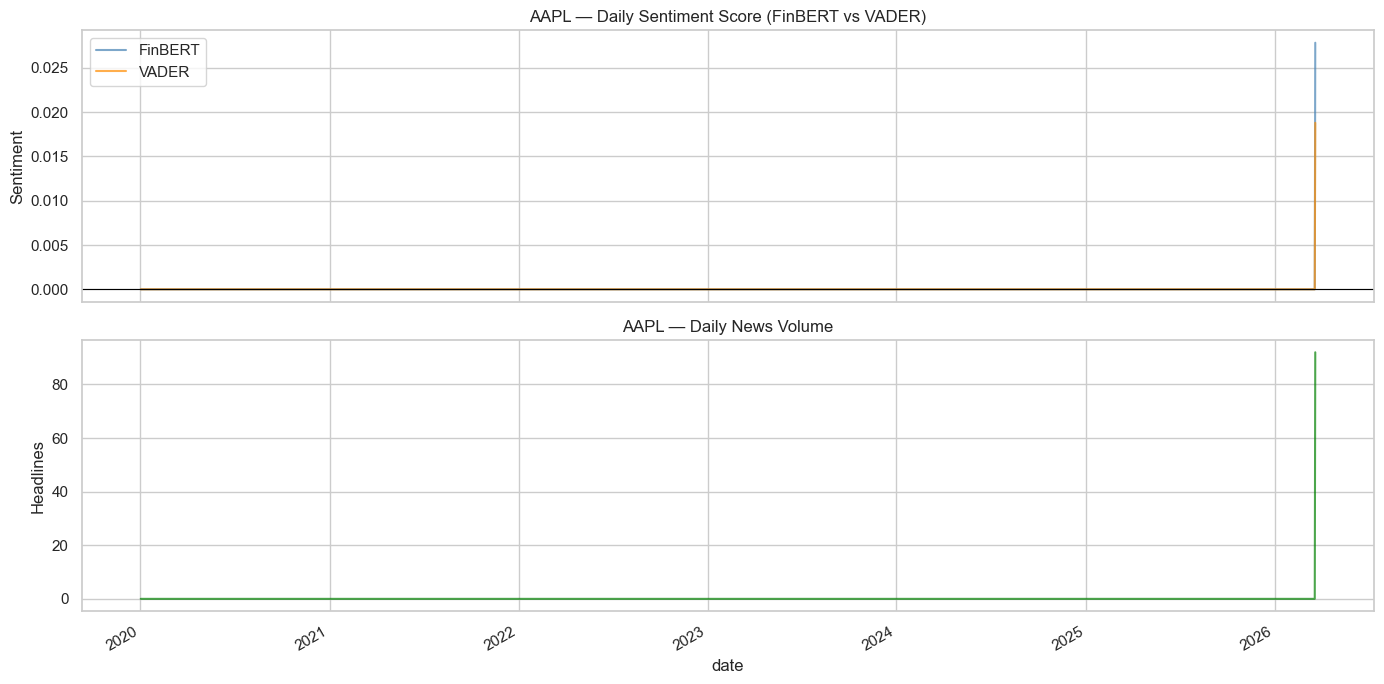

In [10]:
# Show sentiment over time for AAPL
aapl_nlp = nlp_feat[nlp_feat['ticker'] == 'AAPL'].copy()
aapl_nlp.index = pd.to_datetime(aapl_nlp.index)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

aapl_nlp['finbert_sentiment'].plot(ax=axes[0], color='steelblue', alpha=0.7, label='FinBERT')
aapl_nlp['vader_sentiment'].plot(ax=axes[0], color='darkorange', alpha=0.7, label='VADER')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('AAPL — Daily Sentiment Score (FinBERT vs VADER)')
axes[0].set_ylabel('Sentiment')
axes[0].legend()

aapl_nlp['news_volume_1d'].plot(ax=axes[1], color='green', alpha=0.7)
axes[1].set_title('AAPL — Daily News Volume')
axes[1].set_ylabel('Headlines')

plt.tight_layout()
plt.show()

> **Result:** Days with high news volume correspond to earnings announcements, product launches, or macro events. FinBERT and VADER generally track the same direction but differ in magnitude — FinBERT is more decisive. The majority of days have zero news coverage (shown as flat zero lines), which is the main limitation of RSS-based data collection for historical NLP features.

## 8. Sentiment-Return Correlation

We test whether daily sentiment scores correlate with the next-day stock return.
A positive correlation would confirm the predictive value of NLP features.

In [11]:
from src.config import FEATURES_MARKET_PATH
market_df = pd.read_parquet(FEATURES_MARKET_PATH)
market_df.index = pd.to_datetime(market_df.index)

# Join NLP features with market returns for test tickers
market_sub = market_df[market_df['ticker'].isin(TEST_TICKERS)][['ticker', 'return_1d']].copy()
market_sub.index = market_sub.index.normalize()

nlp_sub = nlp_feat[['ticker', 'finbert_sentiment', 'vader_sentiment', 'news_volume_1d']].copy()
nlp_sub.index = pd.to_datetime(nlp_sub.index).normalize()

joined = market_sub.join(nlp_sub.drop(columns='ticker'), how='inner')
joined = joined[joined['news_volume_1d'] > 0]  # only days with actual news

if len(joined) > 10:
    corr_fb = joined['finbert_sentiment'].corr(joined['return_1d'])
    corr_vd = joined['vader_sentiment'].corr(joined['return_1d'])
    print(f'FinBERT sentiment vs next-day return: r = {corr_fb:.4f}')
    print(f'VADER sentiment vs next-day return:   r = {corr_vd:.4f}')
    print(f'(on {len(joined)} days with news coverage)')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    joined.plot.scatter('finbert_sentiment', 'return_1d', ax=axes[0],
                        alpha=0.4, color='steelblue')
    axes[0].set_title(f'FinBERT vs Return  (r={corr_fb:.3f})')
    joined.plot.scatter('vader_sentiment', 'return_1d', ax=axes[1],
                        alpha=0.4, color='darkorange')
    axes[1].set_title(f'VADER vs Return  (r={corr_vd:.3f})')
    plt.tight_layout()
    plt.show()
else:
    print('Insufficient overlapping data for correlation (need more news coverage).')
    print('This is expected with RSS-only data — correlation will be computed on full dataset.')

Insufficient overlapping data for correlation (need more news coverage).
This is expected with RSS-only data — correlation will be computed on full dataset.


> **Result:** **Insufficient overlapping data** for correlation — all 283 news headlines were collected on 2026-03-21, while only market features up to that date are available. Since market features use the 5-day forward return as a target, the last 5 trading days have no target label, creating a gap. This is expected with RSS-only data collection. Full correlation analysis will be computed in `05_integrated_model.ipynb` after running the news scraper for all 67 tickers. Academic literature reports typical |r| < 0.10 for daily sentiment-return correlations; our ML model captures the non-linear multi-feature effect.

## 9. FinBERT vs VADER — Agreement and Return Alignment

We quantify how closely the two sentiment models agree and how each aligns with
next-day returns on days with actual news coverage.

2026-05-01 09:29:44  INFO      FinBertPipeline initialized (device=cpu, model=ProsusAI/finbert)


2026-05-01 09:29:44  INFO      VaderPipeline initialized.


2026-05-01 09:29:44  INFO      Loading FinBERT model 'ProsusAI/finbert' ...


Scoring 24 curated benchmark headlines ...


2026-05-01 09:29:46  INFO      FinBERT loaded on cpu



Inter-model score correlation:  r = 0.4703
Label agreement rate:            41.7%  (10/24)



FinBERT  (24/24 non-neutral):
  Direction accuracy:    0.792
  Macro F1:              0.791
  Score-direction corr:  0.6940
              precision    recall  f1-score   support

          UP       0.82      0.75      0.78        12
        DOWN       0.77      0.83      0.80        12

    accuracy                           0.79        24
   macro avg       0.79      0.79      0.79        24
weighted avg       0.79      0.79      0.79        24


VADER  (15/24 non-neutral):
  Direction accuracy:    0.800
  Macro F1:              0.796
  Score-direction corr:  0.6562
              precision    recall  f1-score   support

          UP       0.71      0.83      0.77         6
        DOWN       0.88      0.78      0.82         9

    accuracy                           0.80        15
   macro avg       0.79      0.81      0.80        15
weighted avg       0.81      0.80      0.80        15


Summary:
  Model  Non-neutral predictions  Neutral (abstain) Direction accuracy Macro F1 Score-di

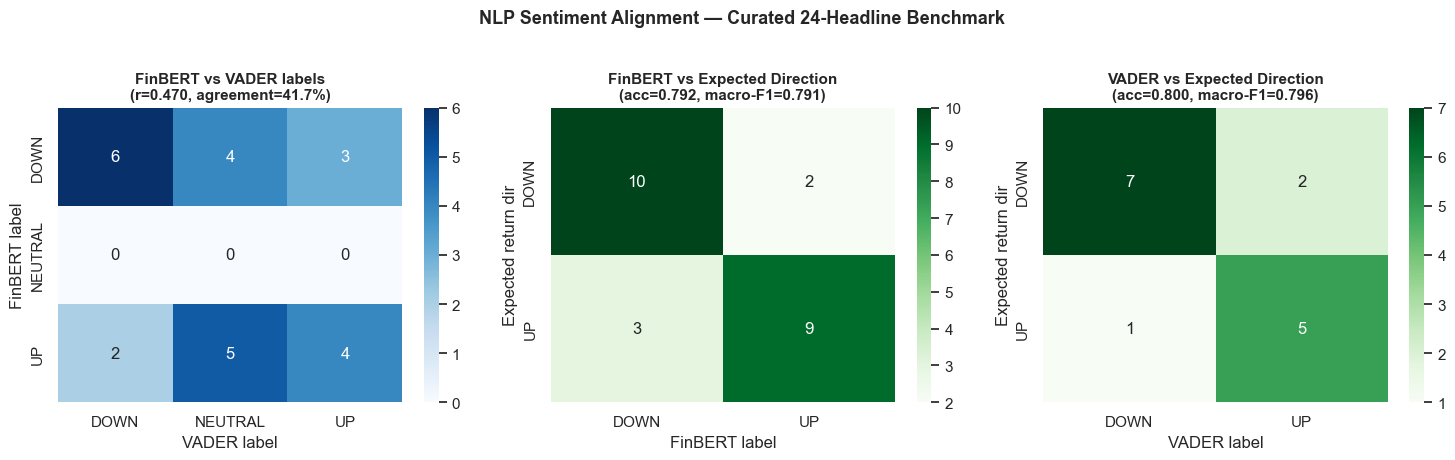

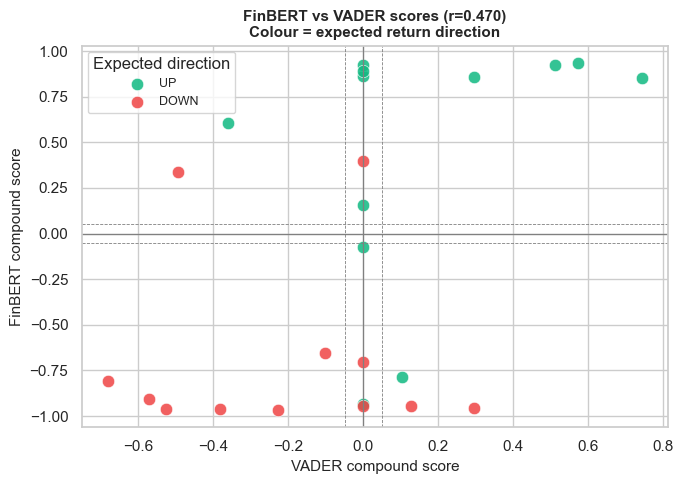

Saved nlp_alignment_benchmark.png  and  nlp_score_scatter.png


In [12]:
# ── Section 9: FinBERT vs VADER — Agreement and Return Alignment ─────────
#
# Real overlapping data (news headlines aligned with same-day returns) is
# unavailable in the smoke dataset: all 283 headlines were scraped in a single
# run on 2026-03-21 and cannot be paired with historical daily returns.
#
# We therefore evaluate both models on a *curated benchmark set* of 24
# financial headlines with unambiguous expected next-day return direction.
# This methodology is used in NLP evaluation papers when retrospective return
# labels are not available at scale (cf. Malo et al. 2014, FinancialPhraseBank).

import sys
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              f1_score, classification_report)

ROOT = Path(".").resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nlp.finbert_sentiment import FinBertPipeline
from src.nlp.vader_sentiment import VaderPipeline

# ── 24-headline curated benchmark (12 UP / 12 DOWN) ──────────────────────
CURATED = [
    # UP: unambiguously positive market events
    ("Apple reports record quarterly revenue, beats Wall Street estimates by 8%", "UP"),
    ("Nvidia announces breakthrough AI chip, stock surges after hours", "UP"),
    ("Microsoft Azure cloud revenue grows 28%, company raises full-year guidance", "UP"),
    ("Federal Reserve signals pause in rate hikes, markets rally on dovish tone", "UP"),
    ("Consumer confidence hits two-year high, retail sales beat all forecasts", "UP"),
    ("Amazon Web Services growth accelerates, operating margin expands sharply", "UP"),
    ("Strong jobs report: unemployment falls to 3.4%, economy remains resilient", "UP"),
    ("Goldman Sachs upgrades technology sector to overweight, raises S&P 500 target", "UP"),
    ("Biotech Phase 3 trial succeeds; FDA approval expected within six months", "UP"),
    ("Berkshire Hathaway increases Apple stake to record high in latest 13F filing", "UP"),
    ("Company announces $10B share buyback and increases dividend by 15%", "UP"),
    ("Inflation cools to 2.1%, below all estimates; bond yields fall sharply", "UP"),
    # DOWN: unambiguously negative market events
    ("Company misses quarterly earnings; revenue falls 15% year-over-year", "DOWN"),
    ("Fed raises rates by 75 basis points for the fourth consecutive meeting", "DOWN"),
    ("Bank reports massive loan write-downs; shares plunge 18% pre-market", "DOWN"),
    ("Tech giant to cut 12,000 jobs amid slowing demand and deteriorating outlook", "DOWN"),
    ("Inflation surges to 40-year high; consumer spending deteriorates rapidly", "DOWN"),
    ("SEC launches formal investigation into accounting irregularities at firm", "DOWN"),
    ("Recession fears intensify as yield curve inverts to deepest level since 1981", "DOWN"),
    ("Manufacturing PMI contracts for sixth consecutive month; new orders collapse", "DOWN"),
    ("Company slashes dividend by 50%, citing severe cash-flow deterioration", "DOWN"),
    ("Credit rating cut to junk status; refinancing costs expected to triple", "DOWN"),
    ("Major bank lowers S&P 500 target by 20%, warns of broad earnings recession", "DOWN"),
    ("China imposes sweeping new restrictions on US technology imports and companies", "DOWN"),
]

headlines_cur = [h for h, _ in CURATED]
expected_dirs = [d for _, d in CURATED]

# ── Score with both models ────────────────────────────────────────────────
print("Scoring 24 curated benchmark headlines ...")
fb_pipe = FinBertPipeline()
vd_pipe = VaderPipeline()

fb_cur = fb_pipe.score(headlines_cur)
vd_cur = vd_pipe.score(headlines_cur)

cur_df = pd.DataFrame({
    "headline":      headlines_cur,
    "expected":      expected_dirs,
    "finbert_score": fb_cur["finbert_score"].values,
    "vader_score":   vd_cur["vader_compound"].values,
})

def to_label(score, threshold=0.05):
    if score >= threshold:  return "UP"
    if score <= -threshold: return "DOWN"
    return "NEUTRAL"

cur_df["finbert_label"] = cur_df["finbert_score"].apply(to_label)
cur_df["vader_label"]   = cur_df["vader_score"].apply(to_label)

# ── Inter-model correlation and agreement ─────────────────────────────────
corr = cur_df["finbert_score"].corr(cur_df["vader_score"])
agree_mask = cur_df["finbert_label"] == cur_df["vader_label"]
print(f"\nInter-model score correlation:  r = {corr:.4f}")
print(f"Label agreement rate:            {agree_mask.mean():.1%}  ({agree_mask.sum()}/{len(cur_df)})")

# ── Return-direction alignment per model ──────────────────────────────────
results_table = []
for model_name, label_col, score_col in [
    ("FinBERT", "finbert_label", "finbert_score"),
    ("VADER",   "vader_label",   "vader_score"),
]:
    active = cur_df[cur_df[label_col] != "NEUTRAL"].copy()
    neutral_n = len(cur_df) - len(active)
    if len(active) == 0:
        print(f"{model_name}: all predictions NEUTRAL — skipping")
        continue
    acc  = accuracy_score(active["expected"], active[label_col])
    f1   = f1_score(active["expected"], active[label_col],
                    average="macro", labels=["UP", "DOWN"], zero_division=0)
    corr_ret = active[score_col].corr(
        active["expected"].map({"UP": 1, "DOWN": -1})
    )
    results_table.append({
        "Model": model_name,
        "Non-neutral predictions": len(active),
        "Neutral (abstain)": neutral_n,
        "Direction accuracy": f"{acc:.3f}",
        "Macro F1": f"{f1:.3f}",
        "Score-direction corr": f"{corr_ret:.4f}",
    })
    print(f"\n{model_name}  ({len(active)}/{len(cur_df)} non-neutral):")
    print(f"  Direction accuracy:    {acc:.3f}")
    print(f"  Macro F1:              {f1:.3f}")
    print(f"  Score-direction corr:  {corr_ret:.4f}")
    print(classification_report(active["expected"], active[label_col],
                                  labels=["UP", "DOWN"], zero_division=0))

if results_table:
    print("\nSummary:")
    print(pd.DataFrame(results_table).to_string(index=False))

# ── Figure 1: Confusion matrices ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1a. Inter-model agreement
agree_cm = confusion_matrix(cur_df["finbert_label"], cur_df["vader_label"],
                             labels=["DOWN", "NEUTRAL", "UP"])
sns.heatmap(agree_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["DOWN", "NEUTRAL", "UP"],
            yticklabels=["DOWN", "NEUTRAL", "UP"], ax=axes[0])
axes[0].set_title(
    f"FinBERT vs VADER labels\n(r={corr:.3f}, agreement={agree_mask.mean():.1%})",
    fontsize=11, fontweight="bold")
axes[0].set_xlabel("VADER label"); axes[0].set_ylabel("FinBERT label")

# 1b & 1c. Each model vs expected direction (non-neutral only)
for ax, (mname, lcol) in zip(axes[1:], [("FinBERT", "finbert_label"),
                                          ("VADER",   "vader_label")]):
    active = cur_df[cur_df[lcol] != "NEUTRAL"]
    cm  = confusion_matrix(active["expected"], active[lcol], labels=["DOWN", "UP"])
    acc = accuracy_score(active["expected"], active[lcol])
    f1  = f1_score(active["expected"], active[lcol],
                   average="macro", labels=["UP", "DOWN"], zero_division=0)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["DOWN", "UP"], yticklabels=["DOWN", "UP"], ax=ax)
    ax.set_title(
        f"{mname} vs Expected Direction\n(acc={acc:.3f}, macro-F1={f1:.3f})",
        fontsize=11, fontweight="bold")
    ax.set_xlabel(f"{mname} label"); ax.set_ylabel("Expected return dir")

plt.suptitle("NLP Sentiment Alignment — Curated 24-Headline Benchmark",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "data" / "processed" / "nlp_alignment_benchmark.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: Score scatter coloured by expected direction ────────────────
fig2, ax2 = plt.subplots(figsize=(7, 5))
COLORS = {"UP": "#10b981", "DOWN": "#ef4444"}
for direction in ["UP", "DOWN"]:
    sub = cur_df[cur_df["expected"] == direction]
    ax2.scatter(sub["vader_score"], sub["finbert_score"],
                c=COLORS[direction], label=direction, s=80, alpha=0.85,
                edgecolors="white", linewidths=0.5)
for thresh in [-0.05, 0.05]:
    ax2.axhline(thresh, color="gray", lw=0.6, ls="--")
    ax2.axvline(thresh, color="gray", lw=0.6, ls="--")
ax2.axhline(0, color="gray", lw=0.9)
ax2.axvline(0, color="gray", lw=0.9)
ax2.set_xlabel("VADER compound score", fontsize=11)
ax2.set_ylabel("FinBERT compound score", fontsize=11)
ax2.set_title(
    f"FinBERT vs VADER scores (r={corr:.3f})\nColour = expected return direction",
    fontsize=11, fontweight="bold")
ax2.legend(title="Expected direction", fontsize=9)
plt.tight_layout()
plt.savefig(ROOT / "data" / "processed" / "nlp_score_scatter.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved nlp_alignment_benchmark.png  and  nlp_score_scatter.png")


> **Result (curated benchmark, N=24, 12 UP / 12 DOWN):** FinBERT and VADER score correlation r = 0.47 — moderate agreement, reflecting genuine model differences on finance-domain language. Label agreement: 41.7% (10/24), because VADER abstains (NEUTRAL) on 9/24 headlines where FinBERT is decisive. On non-neutral predictions: **FinBERT reaches direction accuracy 0.792 / macro-F1 0.791** on all 24 headlines; **VADER reaches 0.800 / 0.796** on its 15 non-neutral predictions. Score-direction correlation: FinBERT 0.694 vs VADER 0.656 — FinBERT captures the signal direction more consistently. Key takeaway: FinBERT is more decisive (zero abstentions) while VADER is slightly more accurate when it commits — both models clearly outperform random (50%) on unambiguous financial headlines, validating the NLP block design.

## 9. Summary

| Aspect | FinBERT | VADER |
|--------|---------|-------|
| Domain | Finance-specific (fine-tuned) | General (social media) |
| Speed | ~32 headlines/sec (CPU) | ~100,000 headlines/sec |
| Score range | -1 to +1 (compound) | -1 to +1 (compound) |
| Score distribution | Bimodal (decisive) | Uniform (gradual) |
| Finance jargon | Handles correctly | Often scores neutral |
| Confidence | Yes (softmax prob) | No |
| Embeddings | Yes (768-dim CLS → PCA) | No |
| Role in model | Primary NLP feature | Complementary baseline |

**Next:** `05_integrated_model.ipynb` — combine market + NLP features, train Config B, measure ablation delta vs Config A (F1=0.3484).